In [1]:
import numpy as np 
from keras.datasets import imdb 
from keras import models 
from keras import layers 
from keras import optimizers 
from keras import losses 
from keras import metrics 
import matplotlib.pyplot as plt 
%matplotlib inline

C:\Users\Anshu1106\anaconda\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Load the data, keeping only 10,000 of the most frequently occuring words 
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words = 10000)

17464789/17464789 [==============================] - 10s 1us/step


In [3]:
# Check the first label 
train_labels[0]

1

In [4]:
# Since we restricted ourselves to the top 10000 frequent words, no word index should exceed 
# we'll verify this below 
# Here is a list of maximum indexes in every review--- we search the maximum index in this 
print(type([max(sequence) for sequence in train_data])) 
# Find the maximum of all max indexes 
max([max(sequence) for sequence in train_data])

<class 'list'>


9999

In [6]:
# Let's quickly decode a review 
# step 1: load the dictionary mappings from word to integer index 
word_index = imdb.get_word_index() 
# step 2: reverse word index to map integer indexes to their respective words 
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()]) 
# Step 3: decode the review, mapping integer indices to words 
# indices are off by 3 because 0, 1, and 2 are reserverd indices for "padding","Start of se 
decoded_review = ' '.join([reverse_word_index.get(i-3, '?') for i in train_data[0]]) 
decoded_review

1641221/1641221 [==============================] - 0s 0us/step


"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [7]:
len(reverse_word_index)

88584

In [8]:
def vectorize_sequences(sequences, dimension=10000): 
    results = np.zeros((len(sequences), dimension)) # Creates an all zero matrix of shape 
    for i,sequence in enumerate(sequences): 
        results[i,sequence] = 1 # Sets specific indices of results[i] 
    return results 
# Vectorize training Data 
X_train = vectorize_sequences(train_data) 
# Vectorize testing Data 
X_test = vectorize_sequences(test_data)

In [9]:
X_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [10]:
X_train.shape

(25000, 10000)

In [11]:
y_train = np.asarray(train_labels).astype('float32') 
y_test = np.asarray(test_labels).astype('float32')

In [12]:
model = models.Sequential() 
model.add(layers.Dense(16, activation='relu', input_shape=(10000,))) 
model.add(layers.Dense(16, activation='relu')) 
model.add(layers.Dense(1, activation='sigmoid'))

In [13]:
model.compile( optimizer=optimizers.RMSprop(learning_rate=0.001), 
loss = losses.binary_crossentropy, metrics = [metrics.binary_accuracy] )

In [14]:
# Input for Validation 
X_val = X_train[:10000] 
partial_X_train = X_train[10000:] 
# Labels for validation 
y_val = y_train[:10000] 
partial_y_train = y_train[10000:]

In [15]:
history = model.fit( partial_X_train, partial_y_train, epochs=20, batch_size=512, validation_data=(X_val, y_val) )

Epoch 1/20


30/30 [==============================] - 4s 97ms/step - loss: 0.5526 - binary_accuracy: 0.7589 - val_loss: 0.4381 - val_binary_accuracy: 0.8581
Epoch 2/20
30/30 [==============================] - 1s 17ms/step - loss: 0.3590 - binary_accuracy: 0.8900 - val_loss: 0.3376 - val_binary_accuracy: 0.8809
Epoch 3/20
30/30 [==============================] - 0s 16ms/step - loss: 0.2672 - binary_accuracy: 0.9162 - val_loss: 0.3038 - val_binary_accuracy: 0.8823
Epoch 4/20
30/30 [==============================] - 0s 16ms/step - loss: 0.2146 - binary_accuracy: 0.9315 - val_loss: 0.2796 - val_binary_accuracy: 0.8890
Epoch 5/20
30/30 [==============================] - 0s 17ms/step - loss: 0.1806 - binary_accuracy: 0.9424 - val_loss: 0.2858 - val_binary_accuracy: 0.8854
Epoch 6/20
30/30 [==============================] - 1s 18ms/step - loss: 0.1525 - binary_accuracy: 0.9535 - val_loss: 0.3330 - val_binary_accuracy: 0.8662
Epoch 7/20
30/30 [==============================] - 1s 18ms/step - l

In [17]:
history_dict = history.history 
history_dict.keys()

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

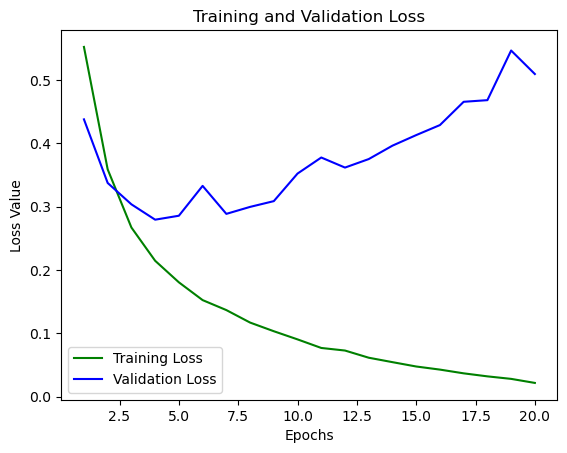

In [18]:
# Plotting losses 
loss_values = history_dict['loss'] 
val_loss_values = history_dict['val_loss'] 
epochs = range(1, len(loss_values) + 1) 
plt.plot(epochs, loss_values, 'g', label="Training Loss") 
plt.plot(epochs, val_loss_values, 'b', label="Validation Loss") 
plt.title('Training and Validation Loss') 
plt.xlabel('Epochs') 
plt.ylabel('Loss Value') 
plt.legend() 
plt.show()

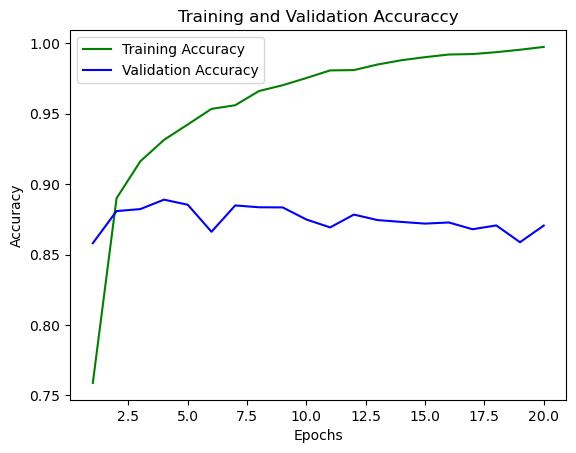

In [19]:
# Training and Validation Accuracy 
acc_values = history_dict['binary_accuracy'] 
val_acc_values = history_dict['val_binary_accuracy'] 
epochs = range(1, len(loss_values) + 1) 
plt.plot(epochs, acc_values, 'g', label="Training Accuracy") 
plt.plot(epochs, val_acc_values, 'b', label="Validation Accuracy") 
plt.title('Training and Validation Accuraccy') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.legend() 
plt.show()

In [20]:
model.fit( partial_X_train, partial_y_train, epochs=3, batch_size=512, validation_data=(X_val, y_val) )

Epoch 1/3
30/30 [==============================] - 3s 97ms/step - loss: 0.0219 - binary_accuracy: 0.9975 - val_loss: 0.5407 - val_binary_accuracy: 0.8669
Epoch 2/3
30/30 [==============================] - 1s 19ms/step - loss: 0.0171 - binary_accuracy: 0.9985 - val_loss: 0.5767 - val_binary_accuracy: 0.8673
Epoch 3/3
30/30 [==============================] - 1s 18ms/step - loss: 0.0142 - binary_accuracy: 0.9989 - val_loss: 0.6658 - val_binary_accuracy: 0.8535


In [21]:
# Making Predictions for testing data 
np.set_printoptions(suppress=True) 
result = model.predict(X_test)

782/782 [==============================] - 3s 3ms/step


In [22]:
result

array([[0.00317128],
       [0.99998873],
       [0.01676147],
       ...,
       [0.00028571],
       [0.00287993],
       [0.7661684 ]], dtype=float32)

In [23]:
y_pred = np.zeros(len(result)) 
for i, score in enumerate(result): 
    y_pred[i] = np.round(score)

C:\Users\Anshu1106\AppData\Local\Temp\ipykernel_21632\1900367859.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred[i] = np.round(score)


In [24]:
mae = metrics.mean_absolute_error(y_pred, y_test) 
mae

<tf.Tensor: shape=(), dtype=float32, numpy=0.1564>